<a href="https://colab.research.google.com/github/Alej00525/programacion1/blob/main/Tarea__5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAREA #5
## Integrantes:
- Jose Alejandro Parra Nieto   - 2260673
- Maria Lucia Higuera Angarita - 2260674
- Joseydy Andrea Perozo Rueda  - 2260665
- Juan Felipe Gonzalez Alfonso - 2260663

La base de datos que se estara revisando se encuentra aqui:

https://microdatos.dane.gov.co/index.php/catalog/680/data-dictionary/F20?file_name=e_capitulos

In [46]:
import pandas as pd
import numpy as np
from google.colab import files

In [10]:
subido = files.upload()

Saving e_capitulos.csv to e_capitulos.csv


In [48]:
import io
e_capitulos = io.BytesIO(subido['e_capitulos.csv'])
e_capitulos = pd.read_csv(e_capitulos, sep = ',', encoding = 'latin-1')
e_capitulos.head(5)

,E_01,E_02,E_03,E_04,E_05,E_06,E_07,E_08,E_09,E_10,E_11,E_12,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN
0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,1,2,1,2
1,1,15.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,2,1,1,1
2,1,20.0,3.0,1.0,1.0,30.0,1.0,1.0,1.0,2,NaN,NaN,3,1,1,1
3,1,22.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,4,1,1,1
4,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,6,1,1,1


In [49]:
tabla_fumar = pd.DataFrame({
'Edad' : e_capitulos['E_02'],                 # Edad de primer consumo de cigarro (1, 64)
'Frecuencia' : e_capitulos['E_05'],           # Consumo en el mes [Si(1), No(2), No comenta(9)]
'Frecuencia mes' : e_capitulos['E_06'],       # Cuantos dias consume cigarro al mes (0, 30)
'Frecuencia dia' : e_capitulos['E_09'],       # Cuantos cigarros consume al dia (0, ~)
'Edad vape' : e_capitulos['E_11'],            # Edad de primer consumo de vape (1, 64)
'Frecuencia vape' : e_capitulos['E_12']       # Consumo en el mes [Si(1), No(2), No comenta(9)]
})
tabla_fumar.head(6)

,Edad,Frecuencia,Frecuencia mes,Frecuencia dia,Edad vape,Frecuencia vape
0,NaN,NaN,NaN,NaN,NaN,NaN
1,15.0,NaN,NaN,NaN,NaN,NaN
2,20.0,1.0,30.0,1.0,NaN,NaN
3,22.0,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
5,18.0,NaN,NaN,NaN,25.0,2.0


In [50]:
tabla_fumar['Frecuencia'] = tabla_fumar['Frecuencia'].fillna(2)               # Los que no han consumido cigarro este mes estan marcados por el numero 2
tabla_fumar['Frecuencia'] = tabla_fumar['Frecuencia'].astype(str)             # Es una variable cualitativa [si(1), no(2)]
tabla_fumar['Frecuencia mes'] = tabla_fumar['Frecuencia mes'].fillna(0)       # No fumaron ningún cigarro este mes
tabla_fumar['Frecuencia dia'] = tabla_fumar['Frecuencia dia'].fillna(0)       # No fumaron ningún cigarro al dia
tabla_fumar.head(6)

,Edad,Frecuencia,Frecuencia mes,Frecuencia dia,Edad vape,Frecuencia vape
0,NaN,2.0,0.0,0.0,NaN,NaN
1,15.0,2.0,0.0,0.0,NaN,NaN
2,20.0,1.0,30.0,1.0,NaN,NaN
3,22.0,2.0,0.0,0.0,NaN,NaN
4,NaN,2.0,0.0,0.0,NaN,NaN
5,18.0,2.0,0.0,0.0,25.0,2.0


In [51]:
tabla_fumar['Frecuencia vape'] = tabla_fumar['Frecuencia vape'].fillna(2)   # Los que no han consumido vape estan marcados por el numero 2
tabla_fumar['Frecuencia vape'] = tabla_fumar['Frecuencia vape'].astype(str) # Es una variable cualitativa [si(1), no(2)]
tabla_fumar.head(6)

,Edad,Frecuencia,Frecuencia mes,Frecuencia dia,Edad vape,Frecuencia vape
0,NaN,2.0,0.0,0.0,NaN,2.0
1,15.0,2.0,0.0,0.0,NaN,2.0
2,20.0,1.0,30.0,1.0,NaN,2.0
3,22.0,2.0,0.0,0.0,NaN,2.0
4,NaN,2.0,0.0,0.0,NaN,2.0
5,18.0,2.0,0.0,0.0,25.0,2.0


In [52]:
tabla_fumar_GENERAL = tabla_fumar.dropna(subset=['Edad']) # Se elimina a las personas que no han probado cigarro en su vida
tabla_fumar_GENERAL.head(6)

,Edad,Frecuencia,Frecuencia mes,Frecuencia dia,Edad vape,Frecuencia vape
1,15.0,2.0,0.0,0.0,NaN,2.0
2,20.0,1.0,30.0,1.0,NaN,2.0
3,22.0,2.0,0.0,0.0,NaN,2.0
5,18.0,2.0,0.0,0.0,25.0,2.0
6,20.0,2.0,0.0,0.0,NaN,2.0
8,13.0,2.0,0.0,0.0,NaN,2.0


In [53]:
tabla_fumar_GENERAL.describe()  # Analisis estadistico basico de los datos

,Edad,Frecuencia mes,Frecuencia dia,Edad vape
count,16557.000000,16557.000000,16557.000000,1706.000000
mean,17.574923,6.018663,1.388355,26.182298
std,4.815842,11.661296,4.747075,10.517861
min,1.000000,0.000000,0.000000,2.000000
25%,15.000000,0.000000,0.000000,18.000000
50%,17.000000,0.000000,0.000000,23.000000
75%,19.000000,3.000000,0.000000,30.000000
max,61.000000,99.000000,100.000000,63.000000


La edad promedio en la que se consume cigarro por primera vez es entre los 17 y 18 años, con una desviacion de 5 años aproximadamente, con un 50% de los encuestados probando el cigarillo antes de los 17 años.
En promedio consumen cigarro 6 dias al mes aunque el 50% de los encuestados reporta no fumar en el mes, de igual manera en promedio consumen un cigarro al dia aproximadamente aunque el 75% de los encuestados reporta no fumar un cigarro diario, lo que quiere decir que en un 25% de la muesta se concentra el mayor consumo de cigarro.

para las personas que llegaron a consumir vaporizador de media inician a los 26 años pero con una desviacion de 10 años y medio.

### A continuacion se mostraran graficas de la edad de primer consumo, cuantos dias al mes consume y cuantas veces al dia consume (estas fueron hechas con herramientes externas).

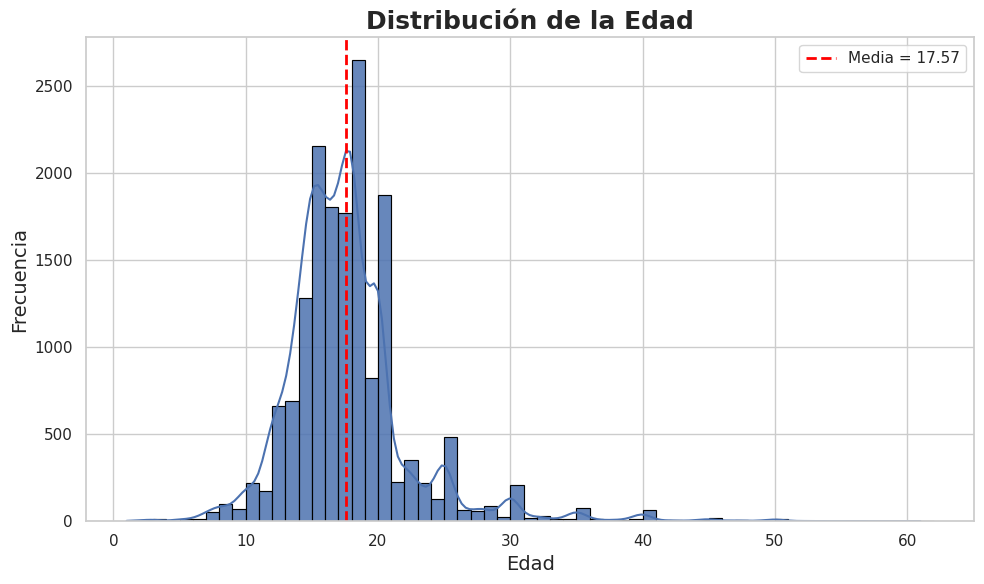

Media edad: 17.574922993295885


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data = tabla_fumar_GENERAL['Edad']
media = data.mean()

plt.figure(figsize=(10, 6))

sns.histplot(
    data,
    bins=range(int(data.min()), int(data.max()) + 2),
    kde=True,
    color='#4C72B0',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribución de la Edad', fontsize=18, weight='bold')
plt.xlabel('Edad', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)

plt.axvline(
    media,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Media = {media:.2f}'
)

plt.legend()
plt.tight_layout()
plt.show()

print("Media edad:", media)

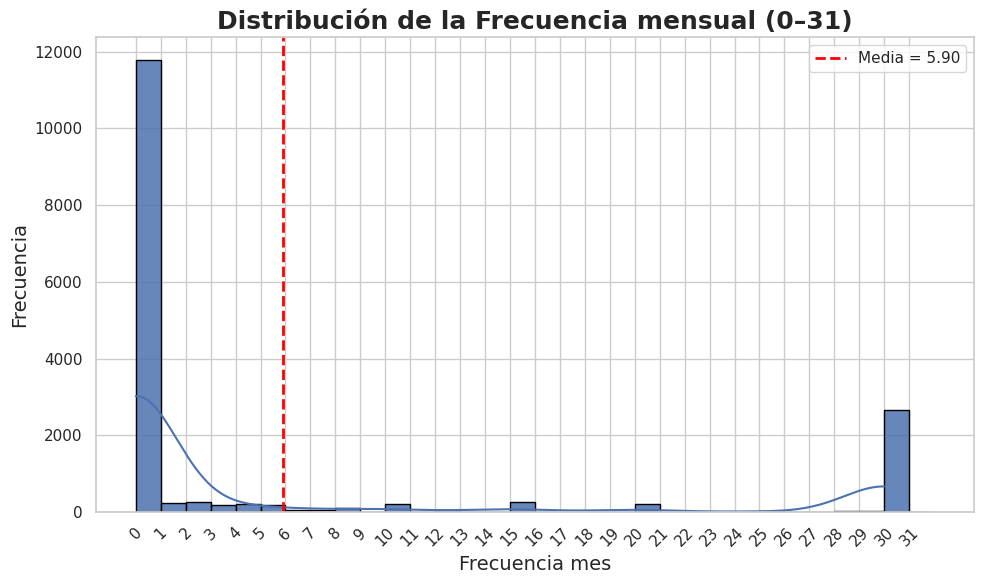

Media (0–31): 5.900580551523948


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Filtrar solo valores válidos (0 a 31)
data = tabla_fumar_GENERAL['Frecuencia mes']
data = data[(data >= 0) & (data <= 31)]

media = data.mean()

plt.figure(figsize=(10, 6))

sns.histplot(
    data,
    bins=range(0, 33),
    kde=True,
    color='#4C72B0',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribución de la Frecuencia mensual (0–31)', fontsize=18, weight='bold')
plt.xlabel('Frecuencia mes', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)

plt.xticks(range(0, 32), rotation=45)

plt.axvline(
    media,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Media = {media:.2f}'
)

plt.legend()
plt.tight_layout()
plt.show()

print("Media (0–31):", media)

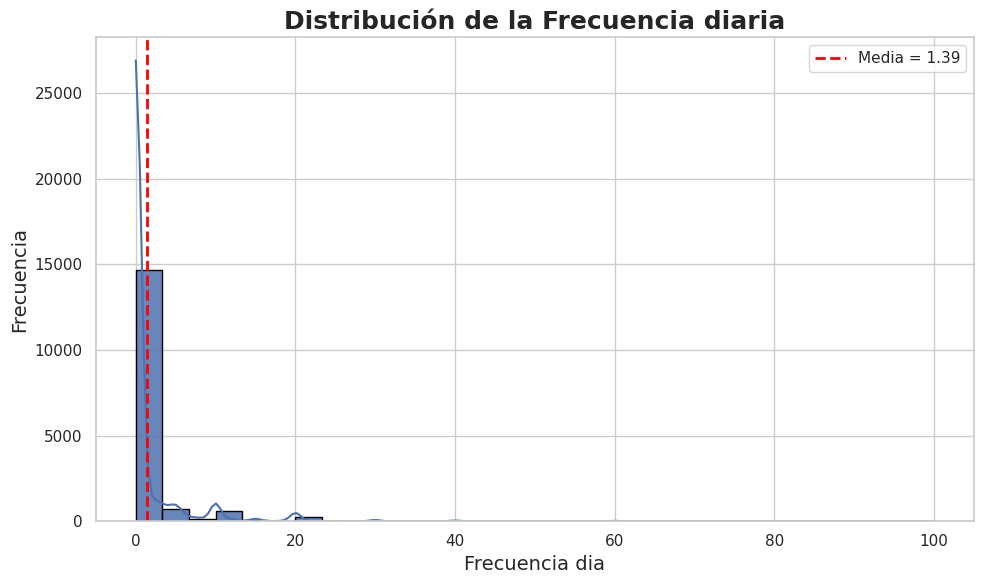

Media frecuencia día: 1.3883553783898048


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data = tabla_fumar_GENERAL['Frecuencia dia']
media = data.mean()

plt.figure(figsize=(10, 6))

sns.histplot(
    data,
    bins=30,
    kde=True,
    color='#4C72B0',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribución de la Frecuencia diaria', fontsize=18, weight='bold')
plt.xlabel('Frecuencia dia', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)

plt.axvline(
    media,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Media = {media:.2f}'
)

plt.legend()
plt.tight_layout()
plt.show()

print("Media frecuencia día:", media)

## Implementación de algoritmos

In [57]:
tabla_fumar1 = tabla_fumar_GENERAL.drop(columns=['Edad vape'])
dataf = pd.get_dummies(
    tabla_fumar1,
    columns=['Frecuencia','Frecuencia vape'],
    prefix=['Frecuencia','Frecuencia vape']
    )
dataf.head(6)

,Edad,Frecuencia mes,Frecuencia dia,Frecuencia_1.0,Frecuencia_2.0,Frecuencia_9.0,Frecuencia vape_1.0,Frecuencia vape_2.0
1,15.0,0.0,0.0,False,True,False,False,True
2,20.0,30.0,1.0,True,False,False,False,True
3,22.0,0.0,0.0,False,True,False,False,True
5,18.0,0.0,0.0,False,True,False,False,True
6,20.0,0.0,0.0,False,True,False,False,True
8,13.0,0.0,0.0,False,True,False,False,True


In [58]:
for col in dataf.columns:
    if col.startswith('Frecuencia_') or col.startswith('Frecuencia vape_'):
        dataf[col] = dataf[col].astype(int)
dataf.head(6)

,Edad,Frecuencia mes,Frecuencia dia,Frecuencia_1.0,Frecuencia_2.0,Frecuencia_9.0,Frecuencia vape_1.0,Frecuencia vape_2.0
1,15.0,0.0,0.0,0,1,0,0,1
2,20.0,30.0,1.0,1,0,0,0,1
3,22.0,0.0,0.0,0,1,0,0,1
5,18.0,0.0,0.0,0,1,0,0,1
6,20.0,0.0,0.0,0,1,0,0,1
8,13.0,0.0,0.0,0,1,0,0,1


In [59]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(dataf, test_size=0.2, random_state=42)

In [60]:
Columnas_con_informacion_extra = [
    'Frecuencia_1.0',
    'Frecuencia_2.0',
    'Frecuencia_9.0',
    'Frecuencia mes' # Eliminar esta porque su valor 0 está directamente relacionado con 'no consume'
]
target_col = 'Frecuencia_1.0'

x_train = train_data.drop(columns=Columnas_con_informacion_extra)
y_train = train_data[target_col]
x_test = test_data.drop(columns=Columnas_con_informacion_extra)
y_test = test_data[target_col]

print("Columnas de x_train después de la corrección:")
print(x_train.columns)

Columnas de x_train después de la corrección:
Index(['Edad', 'Frecuencia dia', 'Frecuencia vape_1.0', 'Frecuencia vape_2.0'], dtype='object')


In [61]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(x_train, y_train)

LinearDiscriminantAnalysis()

In [62]:
y_pred = lda.predict(x_test)
print(f'Predicciones: {y_pred}')

Predicciones: [0 0 0 ... 0 0 0]


In [63]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.99      0.87      2346
           1       0.94      0.31      0.47       966

    accuracy                           0.79      3312
   macro avg       0.86      0.65      0.67      3312
weighted avg       0.82      0.79      0.75      3312



El analisis de discriminante linel arroja una baja precision al momento de predecir posibles consumidores el proximo mes

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2326   20]
 [ 667  299]]


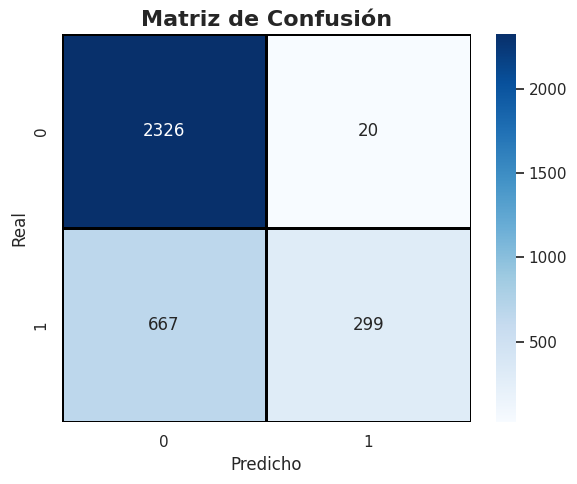

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    linewidths=1,
    linecolor='black'
)

plt.title('Matriz de Confusión', fontsize=16, weight='bold')
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

In [66]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.99      0.87      2346
           1       0.94      0.31      0.47       966

    accuracy                           0.79      3312
   macro avg       0.86      0.65      0.67      3312
weighted avg       0.82      0.79      0.75      3312



La matriz de confusión predice con un 79% de precision si la persona consumira o no cigarros este mes.

In [67]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42)
modelo_rf.fit(x_train, y_train)

y_pred_rf = modelo_rf.predict(x_test)


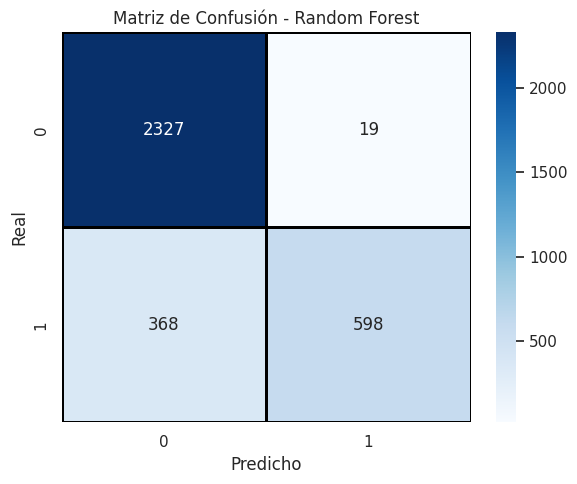

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='black'
)

plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')

plt.tight_layout()
plt.show()

In [69]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      2346
           1       0.97      0.62      0.76       966

    accuracy                           0.88      3312
   macro avg       0.92      0.81      0.84      3312
weighted avg       0.89      0.88      0.87      3312



El modelo Random-Forest posee un 88% de acierto al predecir si alguien consume o no cigarrillo en el ultimo mes.
Aunque puede requerir un balanceo hacia los consumdores al tener un recall bajo de 0.62% es decir que solo identifico al 62% de los consumidores

In [70]:
from sklearn.linear_model import LogisticRegression
modelo_log = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
modelo_log.fit(x_train, y_train)
y_pred_log = modelo_log.predict(x_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      2346
           1       0.97      0.62      0.76       966

    accuracy                           0.88      3312
   macro avg       0.92      0.81      0.84      3312
weighted avg       0.89      0.88      0.88      3312



La regresión logistica posee una precisión muy similar Random-Forest.

Con el proceso de filtrado hasta ahora se puede predecir con cierta precision si la persona fumara almenos una vez el proximo mes.
pero aun falla al decir que efectivamente fumara el proximo mes, asi que, se hara balanceo de los datos reduciendo la muestra

In [71]:
df_filtrado = dataf[(dataf['Edad'] < 14.0)] # Para balancear los datos tomaremos solo las personas q probaron el cigarro antes de los 15 años

In [72]:
df_filtrado

,Edad,Frecuencia mes,Frecuencia dia,Frecuencia_1.0,Frecuencia_2.0,Frecuencia_9.0,Frecuencia vape_1.0,Frecuencia vape_2.0
8,13.0,0.0,0.0,0,1,0,0,1
14,12.0,0.0,0.0,0,1,0,0,1
15,13.0,0.0,0.0,0,1,0,0,1
16,11.0,0.0,0.0,0,1,0,0,1
44,11.0,15.0,0.0,1,0,0,0,1
...,...,...,...,...,...,...,...,...
49700,12.0,15.0,0.0,1,0,0,0,1
49713,11.0,0.0,0.0,0,1,0,0,1
49729,13.0,0.0,0.0,0,1,0,0,1
49736,10.0,0.0,0.0,0,1,0,0,1


In [73]:
df_filtrado.describe()

,Edad,Frecuencia mes,Frecuencia dia,Frecuencia_1.0,Frecuencia_2.0,Frecuencia_9.0,Frecuencia vape_1.0,Frecuencia vape_2.0
count,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000
mean,11.440358,7.579026,2.073062,0.317594,0.681909,0.000497,0.016402,0.983598
std,1.918509,13.036544,5.653964,0.465657,0.465851,0.022294,0.127046,0.127046
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,12.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,13.000000,10.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,13.000000,99.000000,70.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Ahora con la nueva muestra se aplicaran los modelos anteriores para ver si ahora da una mejor aproximación

In [74]:
Columnas_con_informacion_extra

['Frecuencia_1.0', 'Frecuencia_2.0', 'Frecuencia_9.0', 'Frecuencia mes']

In [75]:
# Analisis de discriminante lineal
lda.fit(df_filtrado.drop(columns=Columnas_con_informacion_extra), df_filtrado[target_col])
y1_pred = lda.predict(df_filtrado.drop(columns=Columnas_con_informacion_extra))
cm1 = confusion_matrix(df_filtrado[target_col], y1_pred)
print(cm1)

[[1365    8]
 [ 388  251]]


In [76]:
# Modelo de regresión logistica
modelo_log.fit(df_filtrado.drop(columns=Columnas_con_informacion_extra), df_filtrado[target_col])
y1_pred_log = modelo_log.predict(df_filtrado.drop(columns=Columnas_con_informacion_extra))
cm1 = confusion_matrix(df_filtrado[target_col], y1_pred_log)
print(cm1)

[[1367    6]
 [ 174  465]]


In [77]:
# Modelo Random Forest
modelo_rf.fit(df_filtrado.drop(columns=Columnas_con_informacion_extra), df_filtrado[target_col])
y1_pred_rf = modelo_rf.predict(df_filtrado.drop(columns=Columnas_con_informacion_extra))
cm1 = confusion_matrix(df_filtrado[target_col], y1_pred_rf)
print(cm1)

[[1370    3]
 [ 172  467]]


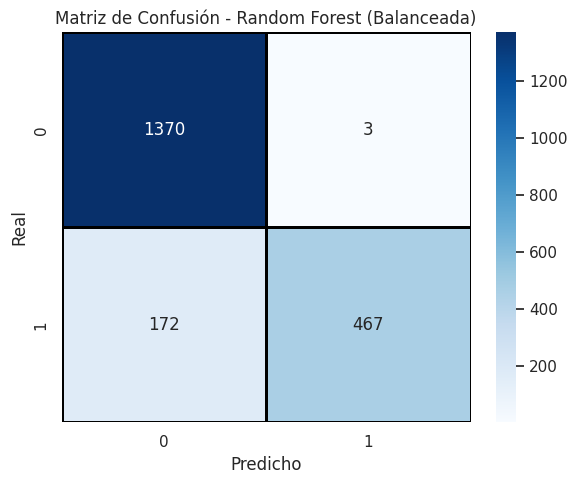

In [78]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm1,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='black'
)

plt.title('Matriz de Confusión - Random Forest (Balanceada)')
plt.xlabel('Predicho')
plt.ylabel('Real')

plt.tight_layout()
plt.show()

In [79]:
print(classification_report(df_filtrado[target_col], y1_pred_rf))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1373
           1       0.99      0.73      0.84       639

    accuracy                           0.91      2012
   macro avg       0.94      0.86      0.89      2012
weighted avg       0.92      0.91      0.91      2012



Como se puede observar, se obtuvo una mejor prediccion si la persona fumara o no el proximo mes con los datos entregados.
Solo que ahora con un enfoque en las personas menores de 14.
Es complejo buscar mayor precision teniendo en cuenta la falta de variables representativas del entorno del individuo.
Esta prediccion se basa unicamente en el consumo actual y el momento en que consumio por primera vez.

In [80]:
# Ahora vamos a probar con un nuevo individuo
individuo = pd.DataFrame({
    'Edad': [15.0],               # Edad de inicio de consumo de cigarro (menor a 14 para ser consistente con df_filtrado)
    'Frecuencia dia': [1.0],      # Cantidad de cigarros que consume al día
    'Frecuencia vape_1.0': [1],   # Si consume vape (1 = Sí, 0 = No)
    'Frecuencia vape_2.0': [0]    # Si no consume vape (1 = No, 0 = Sí)
})
print("Datos del nuevo individuo:")
display(individuo)

Datos del nuevo individuo:


,Edad,Frecuencia dia,Frecuencia vape_1.0,Frecuencia vape_2.0
0,15.0,1.0,1,0


In [81]:
prediccion = modelo_rf.predict(individuo)
print(f'La predicción es: {prediccion}')
if prediccion == 1:
      print('Fumara al menos una vez este mes')
elif prediccion == 0:
      print('No fumara este mes')

La predicción es: [1]
Fumara al menos una vez este mes
